In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df       = pd.read_csv('processed/clean_data.csv', parse_dates=['event_time'])
cat_df   = pd.read_csv('processed/powerbi_category.csv')
rev_df   = pd.read_csv('processed/powerbi_revenue.csv')
funnel   = pd.read_csv('processed/powerbi_funnel.csv')
monthly  = pd.read_csv('processed/powerbi_monthly.csv')

print("✓ All files loaded")

✓ All files loaded


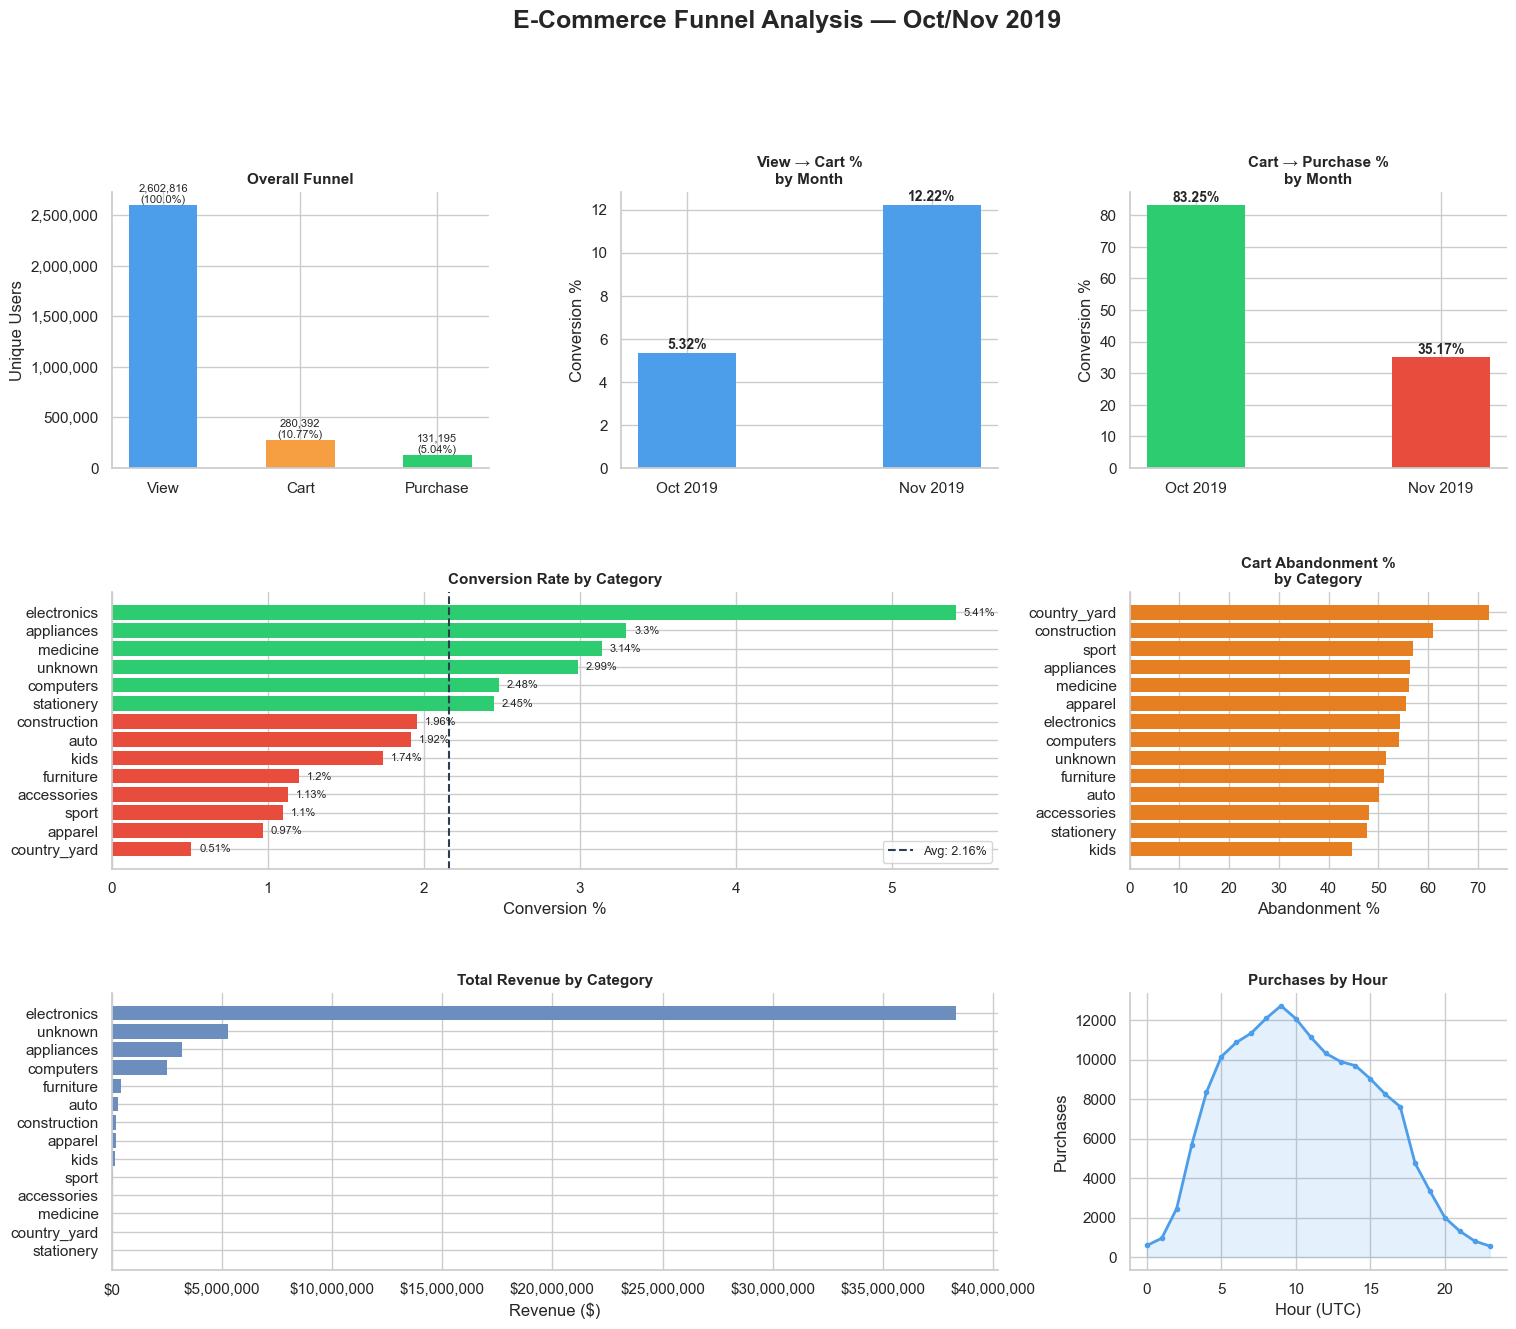

✓ Master dashboard saved!


In [3]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('E-Commerce Funnel Analysis — Oct/Nov 2019', 
             fontsize=18, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Overall Funnel ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_funnel = ['#4C9EEB', '#F59E42', '#2ECC71']
bars = ax1.bar(funnel['stage'], funnel['users'], 
               color=colors_funnel, edgecolor='none', width=0.5)
for bar, val, pct in zip(bars, funnel['users'], funnel['conv_from_view']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20000,
             f'{val:,}\n({pct}%)', ha='center', fontsize=8)
ax1.set_title('Overall Funnel', fontsize=11, fontweight='bold')
ax1.set_ylabel('Unique Users')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top', 'right']].set_visible(False)

# ── Chart 2: Monthly View→Cart ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(monthly['month'], monthly['view_to_cart'], 
        color='#4C9EEB', edgecolor='none', width=0.4)
for i, val in enumerate(monthly['view_to_cart']):
    ax2.text(i, val + 0.2, f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('View → Cart %\nby Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Conversion %')
ax2.spines[['top', 'right']].set_visible(False)

# ── Chart 3: Monthly Cart→Purchase ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(monthly['month'], monthly['cart_to_purchase'],
        color=['#2ECC71', '#E74C3C'], edgecolor='none', width=0.4)
for i, val in enumerate(monthly['cart_to_purchase']):
    ax3.text(i, val + 1, f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Cart → Purchase %\nby Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Conversion %')
ax3.spines[['top', 'right']].set_visible(False)

# ── Chart 4: Category Conversion ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
sorted_cat = cat_df.sort_values('conversion_pct', ascending=True)
avg_conv = cat_df['conversion_pct'].mean()
bar_colors = ['#2ECC71' if x >= avg_conv else '#E74C3C' 
              for x in sorted_cat['conversion_pct']]
ax4.barh(sorted_cat['category'], sorted_cat['conversion_pct'],
         color=bar_colors, edgecolor='none')
ax4.axvline(avg_conv, color='#2C3E50', linestyle='--', 
            linewidth=1.5, label=f'Avg: {avg_conv:.2f}%')
for i, val in enumerate(sorted_cat['conversion_pct']):
    ax4.text(val + 0.05, i, f'{val}%', va='center', fontsize=8)
ax4.set_title('Conversion Rate by Category', fontsize=11, fontweight='bold')
ax4.set_xlabel('Conversion %')
ax4.legend(fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)

# ── Chart 5: Cart Abandonment ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
sorted_abandon = cat_df.sort_values('cart_abandon_pct', ascending=True)
ax5.barh(sorted_abandon['category'], sorted_abandon['cart_abandon_pct'],
         color='#E67E22', edgecolor='none')
ax5.set_title('Cart Abandonment %\nby Category', fontsize=11, fontweight='bold')
ax5.set_xlabel('Abandonment %')
ax5.spines[['top', 'right']].set_visible(False)

# ── Chart 6: Revenue by Category ─────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
rev_sorted = rev_df.sort_values('total_revenue', ascending=True)
ax6.barh(rev_sorted['category_top'], rev_sorted['total_revenue'],
         color='#6C8EBF', edgecolor='none')
ax6.set_title('Total Revenue by Category', fontsize=11, fontweight='bold')
ax6.set_xlabel('Revenue ($)')
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax6.spines[['top', 'right']].set_visible(False)

# ── Chart 7: Hourly Purchases ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
hourly = df[df['event_type'] == 'purchase'].groupby('hour')['user_id'].count()
ax7.plot(hourly.index, hourly.values, color='#4C9EEB', linewidth=2, marker='o', markersize=3)
ax7.fill_between(hourly.index, hourly.values, alpha=0.15, color='#4C9EEB')
ax7.set_title('Purchases by Hour', fontsize=11, fontweight='bold')
ax7.set_xlabel('Hour (UTC)')
ax7.set_ylabel('Purchases')
ax7.spines[['top', 'right']].set_visible(False)

plt.savefig('processed/08_master_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Master dashboard saved!")

In [4]:
purchases = df[df['event_type'] == 'purchase']
total_rev = purchases['price'].sum()
avg_order = purchases['price'].mean()

print("=" * 55)
print("   E-COMMERCE FUNNEL ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print("""
DATASET
───────────────────────────────────────────────────────
  Period    : October – November 2019
  Total rows: ~11M events (sampled from 110M)
  Users     : 2,657,873 unique
  Products  : 169,703 unique
  Categories: 14

FUNNEL PERFORMANCE
───────────────────────────────────────────────────────
  View → Cart      : 10.77%  (89.23% drop-off)
  Cart → Purchase  : 46.79%
  View → Purchase  : 5.04%   (overall conversion)

MONTHLY TREND — KEY FINDING
───────────────────────────────────────────────────────
  November shows classic pre-holiday behavior:
  • View→Cart nearly TRIPLED (5.32% → 12.22%)
  • Cart→Purchase CRASHED (83.25% → 35.17%)
  → Users browsed more and bought less in November
  → High cart abandonment suggests price comparison
    or wishlist behavior before Black Friday

CATEGORY INSIGHTS
───────────────────────────────────────────────────────
  Best converter  : Electronics (5.41%)
  Worst converter : Apparel (0.97%) — 5x gap vs electronics
  Highest abandon : Country_yard (72.22%)
  Most revenue    : Electronics (dominant)

BUSINESS RECOMMENDATIONS
───────────────────────────────────────────────────────
  1. Target apparel cart abandoners with retargeting ads
  2. Launch November checkout incentives (free shipping,
     discount codes) to convert holiday browsers
  3. Double down on electronics — high traffic + conversion
  4. Investigate apparel UX — low conversion may signal
     poor product pages or sizing concerns
""")

print(f"  Total Revenue (sample): ${total_rev:,.2f}")
print(f"  Avg Order Value       : ${avg_order:,.2f}")
print("=" * 55)

   E-COMMERCE FUNNEL ANALYSIS — KEY INSIGHTS

DATASET
───────────────────────────────────────────────────────
  Period    : October – November 2019
  Total rows: ~11M events (sampled from 110M)
  Users     : 2,657,873 unique
  Products  : 169,703 unique
  Categories: 14

FUNNEL PERFORMANCE
───────────────────────────────────────────────────────
  View → Cart      : 10.77%  (89.23% drop-off)
  Cart → Purchase  : 46.79%
  View → Purchase  : 5.04%   (overall conversion)

MONTHLY TREND — KEY FINDING
───────────────────────────────────────────────────────
  November shows classic pre-holiday behavior:
  • View→Cart nearly TRIPLED (5.32% → 12.22%)
  • Cart→Purchase CRASHED (83.25% → 35.17%)
  → Users browsed more and bought less in November
  → High cart abandonment suggests price comparison
    or wishlist behavior before Black Friday

CATEGORY INSIGHTS
───────────────────────────────────────────────────────
  Best converter  : Electronics (5.41%)
  Worst converter : Apparel (0.97%) — 5x ga

In [5]:
import os

files = [
    'processed/clean_data.csv',
    'processed/powerbi_main.csv',
    'processed/powerbi_funnel.csv',
    'processed/powerbi_category.csv',
    'processed/powerbi_revenue.csv',
    'processed/powerbi_monthly.csv',
    'processed/08_master_dashboard.png'
]

print("=== EXPORT FILES READY FOR POWER BI ===\n")
for f in files:
    size = os.path.getsize(f) / 1024**2
    print(f"  ✓ {f:45s} {size:.1f} MB")

print("\n✓ Project analysis complete — ready for Power BI!")

=== EXPORT FILES READY FOR POWER BI ===

  ✓ processed/clean_data.csv                      1293.2 MB
  ✓ processed/powerbi_main.csv                    1293.2 MB
  ✓ processed/powerbi_funnel.csv                  0.0 MB
  ✓ processed/powerbi_category.csv                0.0 MB
  ✓ processed/powerbi_revenue.csv                 0.0 MB
  ✓ processed/powerbi_monthly.csv                 0.0 MB
  ✓ processed/08_master_dashboard.png             0.3 MB

✓ Project analysis complete — ready for Power BI!


In [6]:
import pandas as pd

# Load the monthly file
monthly = pd.read_csv('processed/powerbi_monthly.csv')

# Check what columns exist
print(monthly.columns.tolist())
print(monthly)

['month', 'viewers', 'carters', 'buyers', 'view_to_cart', 'cart_to_purchase', 'view_to_purchase']
      month  viewers  carters  buyers  view_to_cart  cart_to_purchase  \
0  Oct 2019  1365004    72626   60458          5.32             83.25   
1  Nov 2019  1784605   218034   76691         12.22             35.17   

   view_to_purchase  
0              4.43  
1              4.30  


In [7]:
# Reload and resave with month as explicit text
monthly['month'] = monthly['month'].astype(str)
monthly.to_csv('processed/powerbi_monthly.csv', index=False)
print("✓ Saved!")
print(monthly)

✓ Saved!
      month  viewers  carters  buyers  view_to_cart  cart_to_purchase  \
0  Oct 2019  1365004    72626   60458          5.32             83.25   
1  Nov 2019  1784605   218034   76691         12.22             35.17   

   view_to_purchase  
0              4.43  
1              4.30  


In [8]:
# Add a day order column to fix sorting in Power BI
df['day_order'] = df['day_of_week'].map({
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3,
    'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
})

df.to_csv('processed/powerbi_main.csv', index=False)
print("✓ Saved with day order!")

✓ Saved with day order!


In [9]:
import pandas as pd

df = pd.read_csv('processed/clean_data.csv', parse_dates=['event_time'])

df['day_of_week'] = df['event_time'].dt.day_name()
df['day_order'] = df['day_of_week'].map({
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3,
    'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
})

df.to_csv('processed/powerbi_main.csv', index=False)
print("✓ Saved!")
print(df[['day_of_week', 'day_order']].drop_duplicates().sort_values('day_order'))

✓ Saved!
       day_of_week  day_order
762879      Monday          1
0          Tuesday          2
124425   Wednesday          3
243558    Thursday          4
356288      Friday          5
498007    Saturday          6
631041      Sunday          7


In [10]:
import pandas as pd

# Check if day_order exists in the saved file
test = pd.read_csv('processed/powerbi_main.csv', nrows=5)
print(test.columns.tolist())
print(test[['day_of_week', 'day_order']])

['event_time', 'event_type', 'product_id', 'category_code', 'brand', 'price', 'user_id', 'date', 'month_name', 'hour', 'day_of_week', 'category_top', 'day_order']
  day_of_week  day_order
0     Tuesday          2
1     Tuesday          2
2     Tuesday          2
3     Tuesday          2
4     Tuesday          2


In [1]:
readme = """# E-Commerce Funnel Analysis

## Overview
End-to-end funnel analysis of 110M+ e-commerce events from a 
multi-category store (Oct–Nov 2019) using Python and Power BI.

## Dashboard Preview
![Dashboard](processed/08_master_dashboard.png)
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("✓ README.md created!")

✓ README.md created!


In [4]:
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("✓ README.md created!")

✓ README.md created!
